# Player!

This takes the neural network from the mimicry notebook and runs it in realtime connected to the Pyphonic plugin (running standalone or in the DAW).

In [1]:
from pyphonic.src.pyphonic import Pyphonic, midi_parser

In [2]:
import math

import torch
import torch.nn.functional as F
import torch.nn as nn

import numpy as np

# Define the neural network

This must be the same as in the training notebook.

Note that when you train a network on a certain block size (e.g. 512 samples), it must be exactly the same here and in the audio coming from the plugin/DAW, else the neural network will fail because the input's the wrong size. Potentially solveable with masking but I haven't done that.

In [7]:
def actfn(x):
    return torch.tanh(x)
    # bipolar sigmoid
    #return (1 - torch.exp(-x)) / (1 + torch.exp(-x))

class CausalConv1d(torch.nn.Conv1d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, dilation=1, groups=1, bias=True):
        self.__padding = (kernel_size - 1) * dilation

        super(CausalConv1d, self).__init__(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=self.__padding,
            dilation=dilation,
            groups=groups,
            bias=bias,
        )

    def forward(self, input):
        result = super(CausalConv1d, self).forward(input)
        if self.__padding != 0:
            return result[:, :, : -self.__padding]
        return result


def _conv_stack(dilations, in_channels, out_channels, kernel_size):
    """
    Create stack of dilated convolutional layers, outlined in WaveNet paper:
    https://arxiv.org/pdf/1609.03499.pdf
    """
    return nn.ModuleList(
        [
            CausalConv1d(
                in_channels=in_channels,
                out_channels=out_channels,
                dilation=d,
                kernel_size=kernel_size,
            )
            for i, d in enumerate(dilations)
        ]
    )


class Net(nn.Module):
    def __init__(self, num_channels, dilation_depth, num_repeat, kernel_size=2, block_size=512, num_prev_states=50):
        super(Net, self).__init__()
        
        self.block_size = block_size
        self.num_prev_states = num_prev_states
        
        dilations = [2 ** d for d in range(dilation_depth)] * num_repeat
        internal_channels = int(num_channels * 2)
        self.hidden = _conv_stack(dilations, num_channels, internal_channels, kernel_size)
        self.residuals = _conv_stack(dilations, num_channels, num_channels, 1)
        self.input_layer = CausalConv1d(
            in_channels=1,
            out_channels=num_channels,
            kernel_size=1,
        )

        self.linear_mix = nn.Conv1d(
            in_channels=num_channels * dilation_depth * num_repeat,
            out_channels=1,
            kernel_size=1,
        )
        
        self.q_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        self.k_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        self.v_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        
        self.attn = nn.MultiheadAttention(self.block_size, self.block_size//2, bias=True, add_zero_attn=False, dropout=0.2).cuda()
        self.attn_out = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        
        self.residual_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        self.drop = nn.Dropout(0.2)
        self.final_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        
        self.pe = torch.zeros((self.num_prev_states, 1), device='cuda')
        self.pe = self.pe.repeat((1, self.block_size))
        
        self.lpe = nn.Parameter(self.pe)
        # designing a sinusoidal PE was worse
        
        self.bn0 = nn.BatchNorm1d(self.num_prev_states)
        self.bn1 = nn.BatchNorm1d(self.num_prev_states)
        self.bn2 = nn.BatchNorm1d(self.num_prev_states)
        
        self.prior = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        self.levelup = nn.Linear(512, 512, bias=True)
        self.num_channels = num_channels

    def init_hidden(self, bs):
        
        self.past = torch.zeros((bs, self.num_prev_states, self.block_size), device='cuda')
        
        self.past_out = torch.zeros((bs, 1, self.block_size), device='cuda').requires_grad_(True)
        
    def forward(self, x):
        orig_x = x.transpose(2,1)
        
        self.past = x
        
        past = (self.past + self.lpe).requires_grad_(True)
        
        q = actfn(self.q_layer(self.bn0(self.past)[:, -1, :].unsqueeze(1)))
        k = actfn(self.bn1(self.k_layer(past)))
        v = actfn(self.bn2(self.v_layer(past)))
        
        q = q.transpose(1, 0) # (SEQ_LEN, BS, EMBED_DIM)
        k = k.transpose(1, 0)
        v = v.transpose(1, 0)
        
        x, _ = self.attn(q, k, v)
        
        x = x.transpose(1, 0)
        
        #x = actfn(self.attn_out(x))
        
        x = x + self.drop(torch.tanh(self.residual_layer(orig_x[:, :, -1].unsqueeze(2).transpose(2, 1))))#.transpose(2,1)
        
        x = x + self.drop(torch.tanh(self.residual_layer(self.past_out)))# x + self.residual2_layer(self.past_out)
        #x = actfn(self.prior(x)) # bad
        #y1 = torch.atan(self.l0(y1))
        #x = self.final_layer(x)#.transpose(2, 1) # bad
        
        out = x
        skips = []
        out = self.input_layer(out)

        for hidden, residual in zip(self.hidden, self.residuals):
            x1 = out
            out_hidden = hidden(x1)

            out_hidden_split = torch.split(out_hidden, self.num_channels, dim=1)
            out = torch.tanh(out_hidden_split[0]) * torch.sigmoid(out_hidden_split[1])

            skips.append(out)

            out = residual(out)
            out = out + x1[:, :, -out.size(2):]

        out = torch.cat([s[:, :, -out.size(2):] for s in skips], dim=1)
        
        out = self.linear_mix(out)
        
        self.past_out = out.clone().requires_grad_(True)
        
        out = torch.tanh(self.levelup(out))
        return out

In [35]:
class MyCallbackDeepLearning:
    def __init__(self, bpm=120.0, chunk=512, num_prev_states=120):
        self.bpm = bpm
        self.chunk = chunk
        self.num_prev_states = num_prev_states
        self.net = Net(8, 6, 2, 2, num_prev_states=self.num_prev_states) # This was set in the training notebook
        self.net.load_state_dict(torch.load("wavenet_4.bin"))
        self.net.cuda()
        self.net.eval()
        self.net.init_hidden(1) # batch size 2 because incoming audio is stereo
        self.history = torch.zeros((1, self.num_prev_states, self.chunk), device='cuda')
        
        # What you don't capture (because of the way it's trained) is any interplay between the two stereo channels.
    def __call__(self, audio_data, midi_data, bpm=128, chunk_size=512):
        audio_data = torch.tensor(audio_data, dtype=torch.float32, requires_grad=False, device='cuda')
        
        audio_data = audio_data[0].view((1, 1, 512))
        self.history = torch.cat((self.history[:, 1:, :], audio_data), dim=1)
        x = self.history
        
        with torch.no_grad():
            reply = self.net(x)
            
        reply = reply[0].repeat((2, 1))
        
        if audio_data.sum() > 1:
            self.one = audio_data
            self.two = reply

        torch.clamp_(reply, -1, 1)
        reply = reply.cpu().numpy()
        return reply, midi_data

In [36]:
p = Pyphonic(MyCallbackDeepLearning)

In [37]:
p.connect() # Ensure the plugin is running somewhere

In [38]:
p.go() # At this point, sound is coming out :)

'Connection dropped'

In [12]:
import matplotlib.pyplot as plt

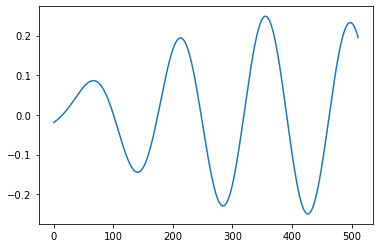

In [13]:
plt.plot(p.callback.one.view(-1).cpu().numpy())

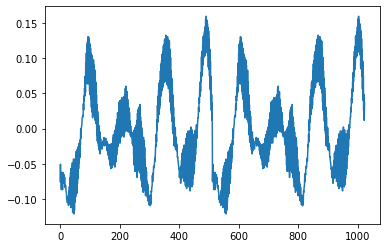

In [14]:
plt.plot(p.callback.two.view(-1).cpu().numpy())